
Na_R1s(r) =
+46.4860 * exp(-15.3319 r)
+23.8044 * exp(-9.0902 r)
+155.7564 * r * exp(-13.2013 r)
+0.1248 * r * exp(-4.7444 r)
+0.0128 * r * exp(-3.1516 r)
-0.0005 * r * exp(-2.4047 r)
-33.5165 * r^2 * exp(-28.4273 r)
+0.0000 * r^2 * exp(-1.3179 r)
-0.0000 * r^2 * exp(-0.8911 r)
+0.0000 * r^2 * exp(-0.6679 r)

Na_R2s(r) =
+6.4502 * exp(-15.3319 r)
-23.6135 * exp(-9.0902 r)
+39.2295 * r * exp(-13.2013 r)
+19.7000 * r * exp(-4.7444 r)
+12.3976 * r * exp(-3.1516 r)
+1.6304 * r * exp(-2.4047 r)
-14.4601 * r^2 * exp(-28.4273 r)
-0.0005 * r^2 * exp(-1.3179 r)
+0.0001 * r^2 * exp(-0.8911 r)
+0.0000 * r^2 * exp(-0.6679 r)

Na_R3s(r) =
+1.3889 * exp(-15.3319 r)
-3.9702 * exp(-9.0902 r)
+8.1626 * r * exp(-13.2013 r)
+3.2654 * r * exp(-4.7444 r)
+1.8292 * r * exp(-3.1516 r)
+0.4361 * r * exp(-2.4047 r)
-0.0516 * r^2 * exp(-28.4273 r)
-0.2023 * r^2 * exp(-1.3179 r)
-0.1328 * r^2 * exp(-0.8911 r)
-0.0420 * r^2 * exp(-0.6679 r)

Na_R2p(r) =
+3.4040 * r * exp(-13.6175 r)
+17.5791 * r * exp(-6.2193 r)

/tmp/ipykernel_16023/1253143935.py:93: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00       8.151185e-02       3.899911e-01       2.053066e+00   
1       0.05       8.150592e-02       3.893895e-01       1.975658e+00   
2       0.10       8.148812e-02       3.875920e-01       1.762170e+00   
3       0.15       8.145848e-02       3.846193e-01       1.460785e+00   
4       0.20       8.141701e-02       3.805055e-01       1.130125e+00   
...      ...                ...                ...                ...   
1996   99.80       8.217725e-08       4.947163e-09       1.130939e-10   
1997   99.85       8.181125e-08       4.925088e-09       1.125891e-10   
1998   99.90       8.144652e-08       4.903089e-09       1.120860e-10   
1999   99.95       8.108304e-08       4.881166e-09       1.115847e-10   
2000  100.00       8.072082e-08       4.859320e-09       1.110851e-10   

      J_2p_one_electron       J_1s(2)       J_2s(2)       J_2p(6)  \
0          2.245681e-01  1.630237e-01  7.799822e-01  1

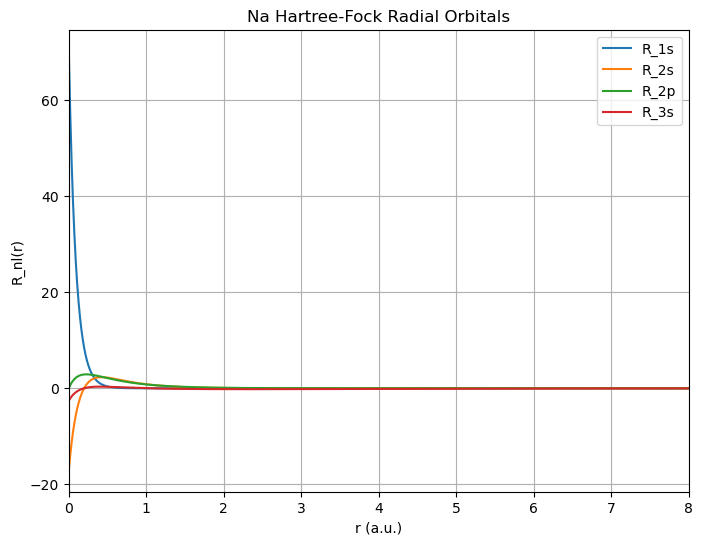

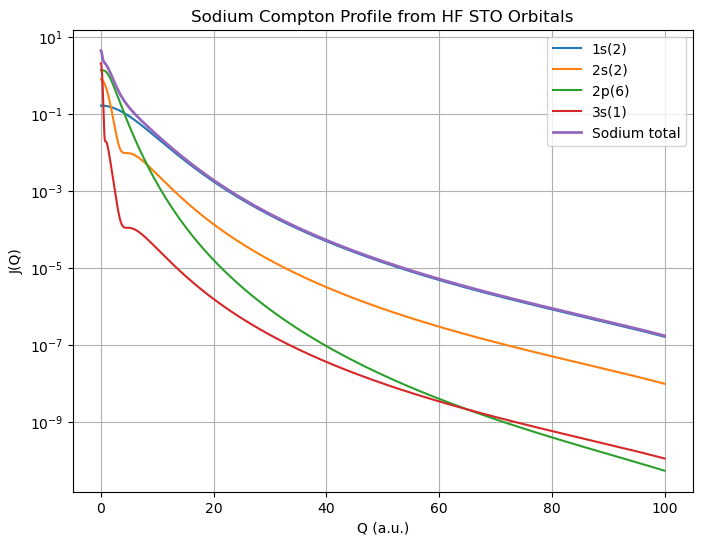

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Sodium Hartree-Fock STO data
# Na: 1s(2) 2s(2) 2p(6) 3s(1)
# Format: (n_j, Z_j, C_j)
# =====================================================

sodium_1s = [
    (1, 15.3319,  0.387167),
    (1,  9.0902,  0.434278),
    (2, 13.2013,  0.213027),
    (2,  4.7444,  0.002205),
    (2,  3.1516,  0.000627),
    (2,  2.4047, -0.000044),
    (3, 28.4273, -0.000649),
    (3,  1.3179,  0.000026),
    (3,  0.8911, -0.000023),
    (3,  0.6679,  0.000008),
]

sodium_2s = [
    (1, 15.3319,  0.053722),
    (1,  9.0902, -0.430794),
    (2, 13.2013,  0.053654),
    (2,  4.7444,  0.347971),
    (2,  3.1516,  0.608890),
    (2,  2.4047,  0.157462),
    (3, 28.4273, -0.000280),
    (3,  1.3179, -0.000492),
    (3,  0.8911,  0.000457),
    (3,  0.6679,  0.000016),
]

sodium_3s = [
    (1, 15.3319,  0.011568),
    (1,  9.0902, -0.072430),
    (2, 13.2013,  0.011164),
    (2,  4.7444,  0.057679),
    (2,  3.1516,  0.089837),
    (2,  2.4047,  0.042114),
    (3, 28.4273, -0.000001),
    (3,  1.3179, -0.182627),
    (3,  0.8911, -0.471631),
    (3,  0.6679, -0.408817),
]

sodium_2p = [
    (2, 13.6175, 0.004308),
    (2,  6.2193, 0.157824),
    (2,  3.8380, 0.388545),
    (2,  2.3633, 0.489339),
    (2,  1.5319, 0.039759),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R

# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build nitrogen radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, sodium_1s)
R2s = R_nl(r, sodium_2s)
R3s = R_nl(r, sodium_3s)
R2p = R_nl(r, sodium_2p)

print_R_formula(sodium_1s, "Na_R1s")
print_R_formula(sodium_2s, "Na_R2s")
print_R_formula(sodium_3s, "Na_R3s")
print_R_formula(sodium_2p, "Na_R2p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

# Nitrogen has 1s(2) 2s(2) 2p(3)
J_total = 2*J_1s + 2*J_2s + J_3s + 6*J_2p
# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(1)": J_3s,
    "J_total_sodium": J_total
})
print(table)
table.to_csv("Sodium_HF_Compton_profile.csv", index=False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Na Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, J_3s, label="3s(1)")
plt.plot(Q, J_total, label="Sodium total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Sodium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()